# Exploración y Diagnóstico — Houses Dataset

Dataset de viviendas con 80 variables sobre características de casas y su precio de venta.
El objetivo declarado es predecir `SalePrice`.

**Antes de aceptar ese objetivo, este notebook responde una pregunta previa:**  
*¿Los datos permiten hacerlo — o hay problemas que invalidan el análisis antes de empezar?*

---

### Cómo pensar este notebook

La exploración no es curiosidad. Es una auditoría con criterio de salida claro.  
Cada sección tiene una pregunta concreta que debe quedar respondida antes de pasar a la siguiente.  
Si una sección no produce una conclusión, no está terminada.

El orden importa:
1. Primero estructura — si los tipos están mal, todos los estadísticos posteriores mienten
2. Luego calidad — nulos y duplicados antes de calcular cualquier cosa
3. Luego distribuciones — para detectar lo que los números no muestran
4. Luego dominio — para detectar lo que las distribuciones tampoco muestran
5. Al final diagnóstico — una sola frase con decisión, no una lista de observaciones

In [3]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUTA_DATOS     = Path('datos') / 'houses.csv'
RUTA_RESULTADO = Path('resultado')
UMBRAL_NULOS   = 0.50  # columnas por encima de este % se consideran drop candidates

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Carga

**Pregunta:** ¿El archivo carga sin errores y el volumen tiene sentido?

Antes de ver una sola columna necesitas saber con qué escala trabajas.  
El número de filas determina si los porcentajes de nulos son alarmantes o tolerables.  
La memoria te dice si puedes operar libremente o si necesitas optimizar tipos antes de continuar.

En esta celda no interpretas nada — solo confirmas que el archivo es lo que te dijeron que era.

In [4]:
df = pd.read_csv(RUTA_DATOS)

print(f'Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Shape: 1,460 filas × 81 columnas
Memoria: 4.0 MB


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,...,0,NaN,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,...,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 2. Estructura

**Pregunta:** ¿Los tipos que pandas infirió son los tipos que realmente tiene cada columna?

Pandas infiere tipos al leer — y se equivoca con frecuencia.  
El error más común: columnas que son códigos o categorías se leen como `int64` o `float64`  
porque sus valores son números. Eso no las hace numéricas en sentido analítico.

La diferencia importa porque:
- Una columna numérica real admite `mean()`, `std()`, correlaciones
- Un código numérico (como `MSSubClass = 60`) no tiene media con significado — es una etiqueta

Aquí separas las columnas en numéricas reales vs categóricas vs códigos disfrazados de número.  
Esa separación guía todas las decisiones de limpieza y encoding posteriores.

In [5]:
conteo_tipos = df.dtypes.value_counts()
print('Distribución de tipos:\n', conteo_tipos)

columnas_numericas   = df.select_dtypes(include='number').columns.tolist()
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()

print(f'\nNuméricas  : {len(columnas_numericas)}')
print(f'Categóricas: {len(columnas_categoricas)}')

Distribución de tipos:
 str        43
int64      35
float64     3
Name: count, dtype: int64

Numéricas  : 38
Categóricas: 43


C:\Users\alefe\AppData\Local\Temp\ipykernel_8920\2528135046.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include='object').columns.tolist()


In [6]:
# MSSubClass y MoSold son códigos, no magnitudes — no tienen sentido como float
columnas_codigo = ['MSSubClass', 'MoSold', 'YrSold']
print('Valores únicos en columnas de código:')
for col in columnas_codigo:
    print(f'  {col}: {sorted(df[col].unique())}')

Valores únicos en columnas de código:
  MSSubClass: [np.int64(20), np.int64(30), np.int64(40), np.int64(45), np.int64(50), np.int64(60), np.int64(70), np.int64(75), np.int64(80), np.int64(85), np.int64(90), np.int64(120), np.int64(160), np.int64(180), np.int64(190)]
  MoSold: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
  YrSold: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010)]


## 3. Nulos

**Pregunta:** ¿Cuánto falta, dónde falta y qué significa que falte?

Un nulo no siempre es un problema — a veces es información.  
La clave es entender el *por qué* del nulo antes de decidir qué hacer con él.

Hay tres tipos de ausencia:
- **MCAR** (Missing Completely At Random): falta por azar, sin patrón. Imputar es razonable.
- **MAR** (Missing At Random): falta por el valor de otra columna. Requiere análisis cruzado.
- **MNAR** (Missing Not At Random): el dato falta *porque* tiene cierto valor. Imputar introduce sesgo.

En este dataset hay un caso especial que rompe la regla general:  
las columnas `Alley`, `PoolQC`, `Fence` y otras usan el string `'NA'` como valor legítimo  
que significa *'la casa no tiene esta característica'*.  
Pandas no lo lee como nulo — pero si no lo detectas, lo tratas como categoría y contaminas el análisis.  

Regla práctica: antes de imputar cualquier columna, pregúntate  
*¿el dato falta porque no se registró — o porque no existe?*

In [7]:
nulos = (
    df.isnull().sum()
    .to_frame('count')
    .assign(pct=lambda x: (x['count'] / len(df) * 100).round(1))
    .query('count > 0')
    .sort_values('pct', ascending=False)
)

print(f'Columnas con NaN reales: {len(nulos)}')
print(nulos)

Columnas con NaN reales: 19
              count   pct
PoolQC         1453 99.50
MiscFeature    1406 96.30
Alley          1369 93.80
Fence          1179 80.80
MasVnrType      872 59.70
FireplaceQu     690 47.30
LotFrontage     259 17.70
GarageType       81  5.50
GarageYrBlt      81  5.50
GarageFinish     81  5.50
GarageQual       81  5.50
GarageCond       81  5.50
BsmtExposure     38  2.60
BsmtFinType2     38  2.60
BsmtQual         37  2.50
BsmtCond         37  2.50
BsmtFinType1     37  2.50
MasVnrArea        8  0.50
Electrical        1  0.10


In [8]:
# Columnas donde 'NA' es un valor válido del dominio, no un dato faltante
# Documentado en el data dictionary de Ames Housing
columnas_na_valido = ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu',
                      'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                      'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

print('Frecuencia del string NA en columnas de dominio:')
for col in columnas_na_valido:
    n = (df[col] == 'NA').sum()
    print(f'  {col}: {n} ({n/len(df)*100:.1f}%)')

Frecuencia del string NA en columnas de dominio:
  Alley: 0 (0.0%)
  PoolQC: 0 (0.0%)
  Fence: 0 (0.0%)
  MiscFeature: 0 (0.0%)
  FireplaceQu: 0 (0.0%)
  GarageType: 0 (0.0%)
  GarageFinish: 0 (0.0%)
  GarageQual: 0 (0.0%)
  GarageCond: 0 (0.0%)
  BsmtQual: 0 (0.0%)
  BsmtCond: 0 (0.0%)
  BsmtExposure: 0 (0.0%)
  BsmtFinType1: 0 (0.0%)
  BsmtFinType2: 0 (0.0%)


In [9]:
drop_candidates = nulos[nulos['pct'] / 100 > UMBRAL_NULOS].index.tolist()
print(f'Drop candidates (>{UMBRAL_NULOS*100:.0f}% NaN): {drop_candidates}')

Drop candidates (>50% NaN): ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


## 4. Duplicados

**Pregunta:** ¿Hay registros repetidos — y si los hay, son errores o son legítimos?

Un duplicado exacto casi siempre es un error de ingesta: el archivo se procesó dos veces,  
se hizo un join mal, o se concatenaron tablas sin deduplicar.

Pero en datasets de transacciones o ventas, dos filas idénticas pueden ser legítimas:  
la misma casa vendida dos veces al mismo precio en el mismo mes es raro pero posible.  

Por eso siempre verificas dos cosas por separado:
1. Duplicados exactos en todas las columnas → casi siempre error
2. Duplicados en el identificador único (`Id`) → siempre error si el Id debe ser único

Si el Id tiene duplicados y las filas son distintas, tienes un problema de diseño del dato  
que no puedes resolver con `drop_duplicates()` — hay que investigar el origen.

In [10]:
duplicados_exactos = df.duplicated().sum()
ids_duplicados     = df['Id'].duplicated().sum()

print(f'Filas exactamente duplicadas : {duplicados_exactos}')
print(f'IDs duplicados               : {ids_duplicados}')

Filas exactamente duplicadas : 0
IDs duplicados               : 0


## 5. Distribuciones numéricas

**Pregunta:** ¿Los rangos y formas de las distribuciones son coherentes con el dominio?

`describe()` te da los estadísticos pero no te dice si tienen sentido.  
Para eso necesitas ver la forma — el histograma revela lo que la media y la desviación ocultan.

Lo que buscas en cada distribución:
- **Asimetría severa** (cola larga a la derecha): frecuente en precios y áreas.  
  Un modelo lineal sobre datos muy asimétricos rinde mal — señal de que necesitarás transformación logarítmica.
- **Picos aislados en cero**: una variable de área con muchos ceros puede significar  
  que las casas sin esa característica están codificadas como 0, no como nulo.
- **Outliers extremos**: un `GrLivArea` de 5000 m² en un dataset de casas residenciales  
  puede ser un error de entrada o una mansión — hay que decidir si incluirla o no.

Aquí no decides nada todavía. Señalas lo que necesita decisión.

In [11]:
df[columnas_numericas].describe().T.sort_values('std', ascending=False)

,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.00,180921.20,79442.50,34900.00,129975.00,163000.00,214000.00,755000.00
LotArea,1460.00,10516.83,9981.26,1300.00,7553.50,9478.50,11601.50,215245.00
GrLivArea,1460.00,1515.46,525.48,334.00,1129.50,1464.00,1776.75,5642.00
MiscVal,1460.00,43.49,496.12,0.00,0.00,0.00,0.00,15500.00
BsmtFinSF1,1460.00,443.64,456.10,0.00,0.00,383.50,712.25,5644.00
BsmtUnfSF,1460.00,567.24,441.87,0.00,223.00,477.50,808.00,2336.00
TotalBsmtSF,1460.00,1057.43,438.71,0.00,795.75,991.50,1298.25,6110.00
2ndFlrSF,1460.00,346.99,436.53,0.00,0.00,0.00,728.00,2065.00
Id,1460.00,730.50,421.61,1.00,365.75,730.50,1095.25,1460.00
1stFlrSF,1460.00,1162.63,386.59,334.00,882.00,1087.00,1391.25,4692.00


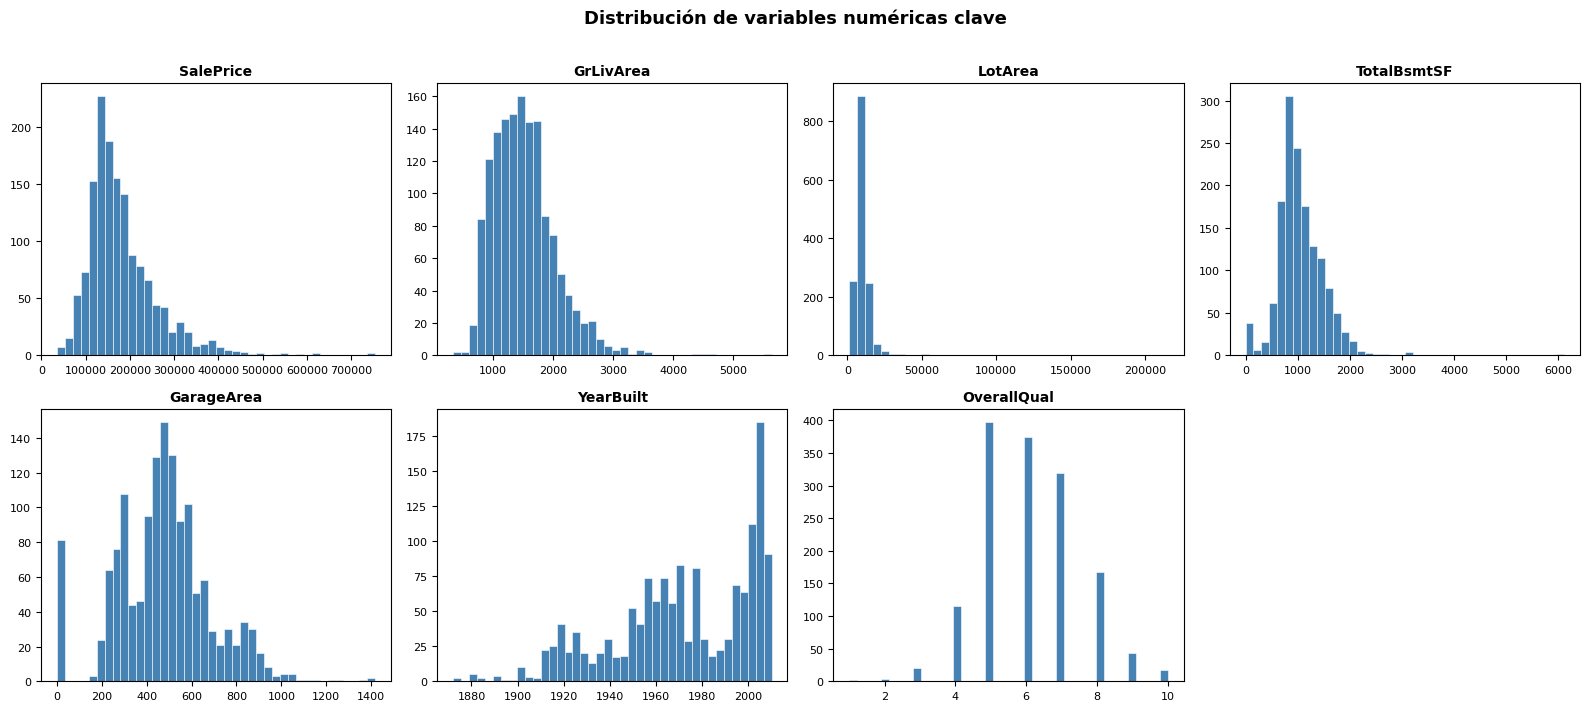

Guardado: resultado/distribucion_numericas.png


In [12]:
columnas_clave = ['SalePrice', 'GrLivArea', 'LotArea', 'TotalBsmtSF',
                  'GarageArea', 'YearBuilt', 'OverallQual']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(columnas_clave):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

axes[-1].set_visible(False)

fig.suptitle('Distribución de variables numéricas clave', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(RUTA_RESULTADO / 'distribucion_numericas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: resultado/distribucion_numericas.png')

## 6. Variables categóricas

**Pregunta:** ¿Las categóricas tienen cardinalidad útil — o están demasiado fragmentadas o demasiado concentradas?

Una variable categórica puede tener dos problemas opuestos:

- **Demasiados valores únicos (alta cardinalidad):** si `Neighborhood` tiene 25 barrios  
  y la mayoría tiene 5 casas, segmentar por barrio produce resultados estadísticamente frágiles.  
  Señal de que necesitarás agrupar categorías antes de analizar.

- **Un valor dominante (concentración extrema):** si el 95% de las casas tiene `Street = Pave`,  
  la columna no discrimina nada útil para el análisis. Es candidata a descartarse.

Lo que miras:
- `unique`: cuántos valores distintos tiene la columna
- `top_pct`: qué porcentaje del total representa el valor más frecuente

Una columna con `top_pct > 95%` casi nunca aporta información.  
Una columna con `unique > 50` necesita estrategia de encoding antes de modelar.

In [13]:
resumen_categoricas = (
    pd.DataFrame({
        'unique'   : df[columnas_categoricas].nunique(),
        'top_valor': df[columnas_categoricas].apply(lambda x: x.value_counts().index[0]),
        'top_pct'  : df[columnas_categoricas].apply(lambda x: x.value_counts(normalize=True).iloc[0] * 100).round(1),
    })
    .sort_values('unique', ascending=False)
)

print(resumen_categoricas)

               unique top_valor  top_pct
Neighborhood       25     NAmes    15.40
Exterior2nd        16   VinylSd    34.50
Exterior1st        15   VinylSd    35.30
Condition1          9      Norm    86.30
SaleType            9        WD    86.80
HouseStyle          8    1Story    49.70
RoofMatl            8   CompShg    98.20
Condition2          8      Norm    99.00
Functional          7       Typ    93.20
BsmtFinType2        6       Unf    88.30
RoofStyle           6     Gable    78.20
BsmtFinType1        6       Unf    30.20
SaleCondition       6    Normal    82.10
Heating             6      GasA    97.80
Foundation          6     PConc    44.30
GarageType          6    Attchd    63.10
ExterCond           5        TA    87.80
LotConfig           5    Inside    72.10
MSZoning            5        RL    78.80
GarageCond          5        TA    96.20
GarageQual          5        TA    95.10
HeatingQC           5        Ex    50.80
Electrical          5     SBrkr    91.40
BldgType        

In [14]:
# Neighborhood es la categórica de mayor interés para análisis de precio
print('Distribución de Neighborhood:')
print(df['Neighborhood'].value_counts())

Distribución de Neighborhood:
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64


## 7. Validación de dominio

**Pregunta:** ¿Los valores son coherentes con las reglas del mundo real?

`describe()` no detecta errores lógicos — solo rangos estadísticos.  
Un año de construcción de `2150` tiene una media normal pero es imposible.  
Un `GarageYrBlt` anterior al `YearBuilt` de la misma casa es una contradicción física.

Las validaciones de dominio deben venir del conocimiento del negocio, no de los datos.  
Antes de escribirlas te preguntas: *¿qué sería un valor imposible en este campo según la realidad?*

Para este dataset:
- Los precios, áreas y superficies no pueden ser cero ni negativos
- Ninguna casa puede haberse construido después de la fecha de venta
- `OverallQual` es una escala del 1 al 10 — cualquier valor fuera de ese rango es error
- El garaje no puede ser más antiguo que la casa

Si algún check falla, no lo corriges aquí — lo documentas. La corrección va en el workflow 04.

In [15]:
anio_actual = 2025

checks = {
    'SalePrice <= 0'           : (df['SalePrice'] <= 0).sum(),
    'GrLivArea <= 0'           : (df['GrLivArea'] <= 0).sum(),
    'LotArea <= 0'             : (df['LotArea'] <= 0).sum(),
    'YearBuilt > anio_actual'  : (df['YearBuilt'] > anio_actual).sum(),
    'YrSold < YearBuilt'       : (df['YrSold'] < df['YearBuilt']).sum(),
    'GarageYrBlt > anio_actual': (df['GarageYrBlt'] > anio_actual).sum(),
    'OverallQual fuera [1,10]' : (~df['OverallQual'].between(1, 10)).sum(),
}

for check, n in checks.items():
    estado = '✓' if n == 0 else f'⚠  {n} registros'
    print(f'  {check:<35}: {estado}')

  SalePrice <= 0                     : ✓
  GrLivArea <= 0                     : ✓
  LotArea <= 0                       : ✓
  YearBuilt > anio_actual            : ✓
  YrSold < YearBuilt                 : ✓
  GarageYrBlt > anio_actual          : ✓
  OverallQual fuera [1,10]           : ✓


## 8. Resumen de calidad por columna

**Pregunta:** ¿Puedo resumir el estado de cada columna en una tabla que le pueda pasar a otro analista?

Este paso convierte todo lo que has visto en una tabla estructurada y exportable.  
Su utilidad es doble:

1. **Para ti:** una referencia rápida cuando empieces el workflow 04 de limpieza.  
   En vez de re-explorar el dataset, abres `resumen_columnas.csv` y sabes exactamente qué necesita qué.

2. **Para otros:** si tienes que justificar una decisión de limpieza ante un compañero o un cliente,  
   esta tabla es la evidencia. *"Eliminé PoolQC porque tiene 99.5% de nulos"* es defendible.  
   *"La eliminé porque no me parecía importante"* no lo es.

La columna `cardinalidad_pct` es especialmente útil: si un identificador tiene `cardinalidad_pct = 100%`,  
confirmas que es realmente único. Si una columna supuestamente categórica tiene `cardinalidad_pct > 50%`,  
hay demasiados valores únicos para ser útil como factor de segmentación.

In [16]:
resumen_columnas = pd.DataFrame({
    'dtype'           : df.dtypes,
    'nulos_pct'       : (df.isnull().mean() * 100).round(1),
    'unicos'          : df.nunique(),
    'cardinalidad_pct': (df.nunique() / len(df) * 100).round(1),
    'muestra'         : [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
})

resumen_columnas.to_csv(RUTA_RESULTADO / 'resumen_columnas.csv')
print('Guardado: resultado/resumen_columnas.csv')
resumen_columnas.sort_values('nulos_pct', ascending=False)

Guardado: resultado/resumen_columnas.csv


,dtype,nulos_pct,unicos,cardinalidad_pct,muestra
PoolQC,str,99.50,3,0.20,Ex
MiscFeature,str,96.30,4,0.30,Shed
Alley,str,93.80,2,0.10,Grvl
Fence,str,80.80,4,0.30,MnPrv
MasVnrType,str,59.70,3,0.20,BrkFace
...,...,...,...,...,...
MoSold,int64,0.00,12,0.80,2
YrSold,int64,0.00,5,0.30,2008
SaleType,str,0.00,9,0.60,WD
SaleCondition,str,0.00,6,0.40,Normal


## 9. Diagnóstico final

**Pregunta:** ¿Puedo resumir el estado del dataset en una sola frase con decisión incluida?

Este es el criterio de salida del workflow. No es un resumen de lo que hiciste —  
es una declaración de lo que encontraste y lo que corresponde hacer a continuación.

La frase tiene una estructura fija:
> *"El dataset tiene [N filas útiles], [X columnas aprovechables],  
> los problemas críticos son [lista priorizada]  
> y el siguiente paso es [workflow / decisión concreta]."*

Si no puedes llenar esa frase, vuelve a las secciones anteriores — falta diagnóstico.  
Si puedes llenarla, el workflow está completo y tienes una base documentada para continuar.

El informe se exporta a `resultado/` para que quede trazabilidad de la diagnosis inicial,  
independientemente de las transformaciones que vengan después.

In [17]:
filas_utiles       = len(df)
cols_aprovechables = len(df.columns) - len(drop_candidates)
problemas_criticos = [
    f'{len(nulos)} columnas con NaN reales',
    f'strings NA legítimos en {len(columnas_na_valido)} columnas (no imputar)',
    f'{len(drop_candidates)} drop candidates por exceso de nulos: {drop_candidates}',
    'MSSubClass y MoSold requieren recodificación de tipo',
]

diagnostico = (
    f'El dataset tiene {filas_utiles:,} filas útiles, {cols_aprovechables} columnas aprovechables, '
    f'los problemas críticos son: {"; ".join(problemas_criticos)}. '
    f'Siguiente paso: workflow 04 — limpieza y transformación.'
)

(RUTA_RESULTADO / 'informe_diagnostico.txt').write_text(diagnostico, encoding='utf-8')

print('── DIAGNÓSTICO FINAL ─────────────────────────────────────────────────')
print(diagnostico)

── DIAGNÓSTICO FINAL ─────────────────────────────────────────────────
El dataset tiene 1,460 filas útiles, 76 columnas aprovechables, los problemas críticos son: 19 columnas con NaN reales; strings NA legítimos en 14 columnas (no imputar); 5 drop candidates por exceso de nulos: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']; MSSubClass y MoSold requieren recodificación de tipo. Siguiente paso: workflow 04 — limpieza y transformación.
